# KernelSynth coverage with pooled seasonal ARIMA-CSS

## Abstract

This experiment tests whether explicit seasonal lag structure covers retained KernelSynth mechanisms beyond AR and ARIMA. Every mechanism is evaluated with periods estimated from its training trajectories. Periodic mechanisms are additionally evaluated with the periods retained by the generator, and the result records whether the selected best model used oracle or data-selected period information. The estimator uses pooled conditional sum of squares and the expanded lag support of multiplicative seasonal AR and MA polynomials.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from tsfmxai.baselines import fit_pooled_arma, one_step_nmse, simulate_pooled_arma
from tsfmxai.evaluation import (
    DEFAULT_THRESHOLDS,
    channel_metrics,
    distribution_metrics,
    dominant_periods,
    passes_channel_coverage,
    passes_coverage,
    violation_score,
)
from tsfmxai.generators import (
    draw_retained_kernel_case,
    draw_retained_lmc_case,
    retained_kernel_cases,
    retained_lmc_mechanisms,
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
CSS_ITERATIONS = 4
MAX_ACF_LAG = 64
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
CROSS_CORR_THRESHOLD = 0.10


MODEL_SHAPES = [
    ((1, 0, 1), (1, 0, 0)),
    ((2, 0, 1), (1, 0, 1)),
    ((2, 1, 1), (1, 0, 0)),
]
SELECTED_PERIOD_COUNT = 2
MAX_SELECTED_PERIOD = 256

def configuration_name(order, seasonal, period, source):
    return f"{source}:ARIMA{tuple(order)}x{tuple(seasonal + (period,))}"

print(f"Seasonal shapes: {MODEL_SHAPES}")

Seasonal shapes: [((1, 0, 1), (1, 0, 0)), ((2, 0, 1), (1, 0, 1)), ((2, 1, 1), (1, 0, 0))]


Three bounded seasonal shapes are tested. Data-selected periods come only from the training periodogram. Oracle periods come from the retained kernel mechanism and are labeled separately in every result row.

In [2]:
CASES = retained_kernel_cases(global_seed=GLOBAL_SEED, length=LENGTH, composition_count=20)
assert len(CASES) == 53
display(pd.DataFrame([{key: case[key] for key in ["id", "category", "family", "periods"]} for case in CASES]))

,id,category,family,periods
0,periodic_01_p24,base,periodic,[24]
1,periodic_02_p48,base,periodic,[48]
2,periodic_03_p96,base,periodic,[96]
3,periodic_04_p168,base,periodic,[168]
4,periodic_05_p336,base,periodic,[336]
5,periodic_06_p672,base,periodic,[672]
6,periodic_07_p7,base,periodic,[7]
7,periodic_08_p14,base,periodic,[14]
8,periodic_09_p30,base,periodic,[30]
9,periodic_10_p60,base,periodic,[60]


The mechanism set matches the AR and ARIMA experiments exactly. Composite cases may contain several retained periodicities because additions and products can combine seasonal structures.

In [3]:
rows = []
reference_series = {}
for case_index, case in enumerate(CASES):
    train, test = draw_retained_kernel_case(case, case_index=case_index, global_seed=GLOBAL_SEED,
                                            n_train=N_TRAIN, n_test=N_TEST)
    reference_series[case["id"]] = test[0].copy()
    period_candidates = [("data_selected", period) for period in dominant_periods(
        train, count=SELECTED_PERIOD_COUNT, maximum=MAX_SELECTED_PERIOD)]
    period_candidates += [("oracle", int(period)) for period in case["periods"]]
    period_candidates = list(dict.fromkeys(period_candidates))
    for candidate_index, (period_source, period) in enumerate(period_candidates):
        for shape_index, (order, seasonal_shape) in enumerate(MODEL_SHAPES):
            seasonal_order = seasonal_shape + (period,)
            configuration = configuration_name(order, seasonal_shape, period, period_source)
            try:
                fit = fit_pooled_arma(train, order=order, seasonal_order=seasonal_order,
                                      ridge=RIDGE, css_iterations=CSS_ITERATIONS)
                if fit.start >= LENGTH - MAX_ACF_LAG - 1:
                    raise ValueError(f"initialization prefix {fit.start} leaves insufficient evaluation data")
                generated = simulate_pooled_arma(
                    fit, test[:, :fit.start], length=LENGTH,
                    rng=np.random.default_rng(GLOBAL_SEED + 7_000_000 + 10000 * case_index
                                              + 100 * candidate_index + shape_index),
                )
                metrics = distribution_metrics(test, generated, fit.start, max_acf_lag=MAX_ACF_LAG)
                forecast_nmse = one_step_nmse(fit, test); error = None
            except Exception as exc:
                metrics = {key: float("inf") for key in THRESHOLDS}
                forecast_nmse = float("inf"); error = f"{type(exc).__name__}: {exc}"
            rows.append({"function": case["id"], "category": case["category"], "family": case["family"],
                         "formula": case["formula"], "periods": ",".join(map(str, case["periods"])),
                         "configuration": configuration, "order": int(max(order[0], order[2], period)),
                         "nonseasonal_ar_order": order[0], "difference_order": order[1],
                         "nonseasonal_ma_order": order[2],
                         "seasonal_ar_order": seasonal_shape[0],
                         "seasonal_difference_order": seasonal_shape[1],
                         "seasonal_ma_order": seasonal_shape[2],
                         "seasonal_period": period, "period_source": period_source,
                         "forecast_nmse": forecast_nmse, **metrics,
                         "well_covered": passes_coverage(metrics, THRESHOLDS), "error": error})

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(lambda row: violation_score(row, thresholds=THRESHOLDS), axis=1)
best = (results.sort_values(["function", "violation_score", "forecast_nmse", "configuration"])
        .groupby("function", as_index=False).first())
status = results.groupby("function")["well_covered"].any().rename("well_covered_any_order").reset_index()
best = best.merge(status, on="function")
source_summary = (results.groupby(["period_source", "function"])["well_covered"].any().reset_index()
                  .groupby("period_source")["well_covered"].mean())
display(best[["function", "family", "configuration", "period_source", "seasonal_period",
              "well_covered_any_order", "acf_mae", "psd_jsd", "abs_log_variance_ratio",
              "standardized_wasserstein", "forecast_nmse"]].round(4))

C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:197: RuntimeWarning: overflow encountered in square
  return float(np.mean((target - predicted) ** 2) / (np.var(target) + 1e-12))


C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:154: RuntimeWarning: overflow encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient
C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:154: RuntimeWarning: invalid value encountered in add
  prediction += residuals[:, time_index - lag] @ coefficient


C:\Users\mateu\repos\tsfmxai\.venv\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


,function,family,configuration,period_source,seasonal_period,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,forecast_nmse
0,composite_01,composite,"data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 2)",data_selected,2,True,0.0712,0.0252,0.0924,0.0799,0.000000e+00
1,composite_02,composite,"data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 26)",data_selected,26,False,0.2477,0.4458,0.1837,0.1075,3.640341e+49
2,composite_03,composite,"oracle:ARIMA(1, 0, 1)x(1, 0, 0, 7)",oracle,7,False,0.2092,0.1300,0.3876,0.1833,3.900000e-03
3,composite_04,composite,"data_selected:ARIMA(1, 0, 1)x(1, 0, 0, 12)",data_selected,12,False,0.0765,0.1823,0.1918,0.1637,4.058978e+99
4,composite_05,composite,"data_selected:ARIMA(1, 0, 1)x(1, 0, 0, 12)",data_selected,12,True,0.0615,0.0004,0.0805,0.0427,0.000000e+00
5,composite_06,composite,"oracle:ARIMA(2, 0, 1)x(1, 0, 1, 48)",oracle,48,False,0.1333,0.0521,0.6781,0.3202,2.285643e+16
6,composite_07,composite,"oracle:ARIMA(2, 0, 1)x(1, 0, 1, 60)",oracle,60,False,0.0928,0.1769,0.6902,0.3258,5.181000e-01
7,composite_08,composite,"oracle:ARIMA(2, 0, 1)x(1, 0, 1, 672)",oracle,672,False,0.0822,0.0379,0.5299,0.1971,1.590000e-02
8,composite_09,composite,"oracle:ARIMA(2, 0, 1)x(1, 0, 1, 672)",oracle,672,True,0.0026,0.0001,0.0088,0.0061,1.000000e-04
9,composite_10,composite,"data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 14)",data_selected,14,False,0.1359,0.0140,0.6373,0.3029,5.286621e+05


Every fitted model is evaluated on fresh trajectories from the same retained mechanism. A long seasonal period is skipped only when its required initialization prefix leaves too little data for the unchanged ACF metric.

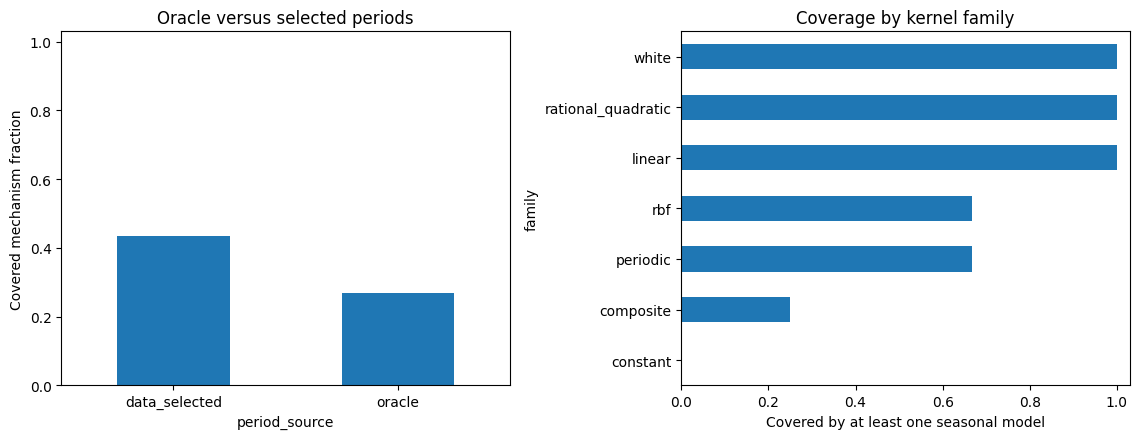

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
source_summary.plot.bar(ax=axes[0], rot=0); axes[0].set_ylim(0, 1.03)
axes[0].set_ylabel("Covered mechanism fraction"); axes[0].set_title("Oracle versus selected periods")
best.groupby("family")["well_covered_any_order"].mean().sort_values().plot.barh(ax=axes[1])
axes[1].set_xlim(0, 1.03); axes[1].set_xlabel("Covered by at least one seasonal model")
axes[1].set_title("Coverage by kernel family")
fig.tight_layout(); plt.show()

The period-source plot prevents oracle period knowledge from being interpreted as automatic seasonal discovery. The family plot uses the best valid seasonal configuration for each mechanism.

In [5]:
covered_functions = best.loc[best.well_covered_any_order, "function"].tolist()
not_covered_functions = best.loc[~best.well_covered_any_order, "function"].tolist()
diagnostic_series = [{"benchmark": "kernelsynth", "mechanism": function,
                      "evaluation_mode": "univariate", "values": reference_series[function].tolist()}
                     for function in not_covered_functions]
print(f"WELL COVERED ({len(covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["function", "formula", "configuration", "period_source", "well_covered_any_order"]])

WELL COVERED (29/53):
  - composite_01
  - composite_05
  - composite_09
  - composite_14
  - composite_18
  - linear_sigma0
  - linear_sigma1
  - linear_sigma10
  - periodic_02_p48
  - periodic_03_p96
  - periodic_04_p168
  - periodic_05_p336
  - periodic_06_p672
  - periodic_10_p60
  - periodic_11_p365
  - periodic_12_p730
  - periodic_13_p4
  - periodic_15_p52
  - periodic_16_p4
  - periodic_17_p6
  - periodic_19_p4
  - periodic_20_p40
  - rbf_scale1
  - rbf_scale10
  - rq_alpha0.1
  - rq_alpha1
  - rq_alpha10
  - white_level0.1
  - white_level1

NOT WELL COVERED (24/53):
  - composite_02
  - composite_03
  - composite_04
  - composite_06
  - composite_07
  - composite_08
  - composite_10
  - composite_11
  - composite_12
  - composite_13
  - composite_15
  - composite_16
  - composite_17
  - composite_19
  - composite_20
  - constant_1
  - periodic_01_p24
  - periodic_07_p7
  - periodic_08_p14
  - periodic_09_p30
  - periodic_14_p26
  - periodic_18_p12
  - periodic_21_p10
  - rbf_s

,function,formula,configuration,period_source,well_covered_any_order
0,composite_01,"((ExpSineSquared(length_scale=1, periodicity=4...","data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 2)",data_selected,True
1,composite_02,"(((ExpSineSquared(length_scale=1, periodicity=...","data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 26)",data_selected,False
2,composite_03,"((((ExpSineSquared(length_scale=1, periodicity...","oracle:ARIMA(1, 0, 1)x(1, 0, 0, 7)",oracle,False
3,composite_04,"(((((ExpSineSquared(length_scale=1, periodicit...","data_selected:ARIMA(1, 0, 1)x(1, 0, 0, 12)",data_selected,False
4,composite_05,"((ExpSineSquared(length_scale=1, periodicity=1...","data_selected:ARIMA(1, 0, 1)x(1, 0, 0, 12)",data_selected,True
5,composite_06,(((ConstantKernel(constant_value=1)) + (ExpSin...,"oracle:ARIMA(2, 0, 1)x(1, 0, 1, 48)",oracle,False
6,composite_07,"((((ExpSineSquared(length_scale=1, periodicity...","oracle:ARIMA(2, 0, 1)x(1, 0, 1, 60)",oracle,False
7,composite_08,"(((((ExpSineSquared(length_scale=1, periodicit...","oracle:ARIMA(2, 0, 1)x(1, 0, 1, 672)",oracle,False
8,composite_09,"((ExpSineSquared(length_scale=1, periodicity=2...","oracle:ARIMA(2, 0, 1)x(1, 0, 1, 672)",oracle,True
9,composite_10,"(((RationalQuadratic(length_scale=1, alpha=10)...","data_selected:ARIMA(2, 0, 1)x(1, 0, 1, 14)",data_selected,False


The failure list records which period source produced the closest model and retains one reference trajectory per failed mechanism for the final three-family intersection.

In [6]:
def git_output(*args):
    try:
        return subprocess.check_output(["git", *args], cwd=REPO_ROOT, text=True).strip()
    except Exception as exc:
        return f"unavailable: {exc}"

function_manifest = [
    {key: case[key] for key in ["id", "category", "family", "formula", "periods"]}
    for case in CASES
]

experiment_record = {
    "experiment_id": "kernelsynth_sarima_css_coverage_001", "status": "completed",
    "research_question": "Which retained KernelSynth mechanisms are well covered by pooled seasonal ARIMA-CSS with oracle or data-selected periods?",
    "hypothesis": "Explicit seasonal lags improve periodic-kernel coverage, especially with oracle periods, while smooth and composite covariance can remain difficult.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST,
                      "model_shapes": [{"order": list(order), "seasonal_shape": list(seasonal)}
                                       for order, seasonal in MODEL_SHAPES],
                      "selected_period_count": SELECTED_PERIOD_COUNT,
                      "max_selected_period": MAX_SELECTED_PERIOD, "ridge": RIDGE,
                      "css_iterations": CSS_ITERATIONS, "max_acf_lag": MAX_ACF_LAG,
                      "thresholds": THRESHOLDS, "functions": function_manifest,
                      "estimator": "pooled CSS with expanded multiplicative seasonal lag support"},
    "provenance": {"kernel_repository": "https://github.com/amazon-science/chronos-forecasting",
                   "kernel_commit": "10afa9ebe016e514f9d7dc1aa873f66af57e116b",
                   "kernel_source": "scripts/kernel-synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED,
                   "policy": "same retained train/test draws as AR/ARIMA; simulation seed derived per function, period candidate, and model shape"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_period_source": {str(k): float(v) for k, v in source_summary.items()},
                "best_row_per_function": best.to_dict(orient="records")},
    "covered_functions": covered_functions, "not_well_covered_functions": not_covered_functions,
    "diagnostic_series": diagnostic_series,
    "scientific_summary": f"{len(covered_functions)}/{len(best)} retained KernelSynth mechanisms were covered by at least one seasonal ARIMA-CSS configuration.",
    "limitations": ["Oracle-period and data-selected results must be interpreted separately.",
                    "Expanded seasonal lag support is estimated without exact nonlinear multiplicative parameter constraints.",
                    "Operational thresholds need sensitivity analysis.", "No Monte Carlo confidence intervals."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\SARIMA\01_kernelsynth_sarima_coverage.ipynb --output 01_kernelsynth_sarima_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False, default=lambda value: float(value)))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "kernelsynth_sarima_css_coverage_001",
  "status": "completed",
  "research_question": "Which retained KernelSynth mechanisms are well covered by pooled seasonal ARIMA-CSS with oracle or data-selected periods?",
  "hypothesis": "Explicit seasonal lags improve periodic-kernel coverage, especially with oracle periods, while smooth and composite covariance can remain difficult.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "model_shapes": [
      {
        "order": [
          1,
          0,
          1
        ],
        "seasonal_shape": [
          1,
          0,
          0
        ]
      },
      {
        "order": [
          2,
          0,
          1
        ],
        "seasonal_shape": [
          1,
          0,
          1
        ]
      },
      {
        "order": [
          2,
          1,
          1
        ],
        "seasonal_shape": [
          1,
          0,
          0
        

The complete record explicitly identifies period provenance and the seasonal estimator approximation, which are required to interpret apparent gains over ARIMA.